In [1]:
import torch.nn as nn
import torch #to use the autograd functionality of PyTorch
import numpy as np

import matplotlib.pyplot as plt #to plot the graph
import torch.nn.functional as F #to use the tanh activation function 
import random #to generate random numbers for training data
import math


/home/pradyun/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
class Model(nn.Module):
    def __init__(self,input_size, output_size, hidden_size1, hidden_size2, hidden_size3):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size1)
        self.linear2 = nn.Linear(hidden_size1, hidden_size2)
        self.linear3 = nn.Linear(hidden_size2, hidden_size3)
        self.linear4 = nn.Linear(hidden_size3, output_size) # the four linear layers 
    def forward(self, x):
        x = self.linear1(x)
        x = torch.tanh(x)
        x = self.linear2(x)
        x = torch.tanh(x)
        x = self.linear3(x)
        x = torch.tanh(x)
        x = self.linear4(x)
        return x

In [3]:
loss_fn = F.mse_loss #the mean square loss funtion w

In [4]:
model = Model(1, 1, 30, 30, 30) #the model with 1 input and 1 output and three hidden layers of size 30 each
x = torch.tensor([1.0], requires_grad=True)
u = model(x)
du_dx = torch.autograd.grad(u, x, create_graph=True)[0]
d2u_dx2 = torch.autograd.grad(du_dx, x)[0]

In [5]:
# Define optimizer
opt = torch.optim.Adam(model.parameters(), lr=0.001)

In [17]:
# Utility function to train the model
def fit(num_epochs, model, loss_fn, opt):
    
    # Repeat for given number of epochs
    for epoch in range(num_epochs):
        
        # Train with batches of data
        for x_val in [random.uniform(-math.pi, math.pi) for _ in range(10)]: #generate 10 random numbers between -π and π for training data
            x = torch.tensor([x_val], requires_grad=True) #convert the random number to a tensor and set requires_grad to True to compute gradients
            pred = model(x)
            h = 1e-5 #a small number to compute the numerical derivative
            # 2. Calculate loss
            l = 0.1 #the weight for the loss term that enforces the PDE constraint
            loss = loss_fn((model(x+h)-model(x))/h , torch.cos(x)) + l*loss_fn(pred, torch.sin(x)) #the target is the cos of x, since we are trying to learn the function cos(x)
            
            # 3. Compute gradients
            loss.backward()
            
            # 4. Update parameters using gradients
            opt.step()
            
            # 5. Reset the gradients to zero
            opt.zero_grad()
        
        # Print the progress
        if (epoch+1) % 1000 == 0:
            print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))


In [18]:
fit(1000, model, loss_fn, opt)

Epoch [1000/1000], Loss: 0.0001


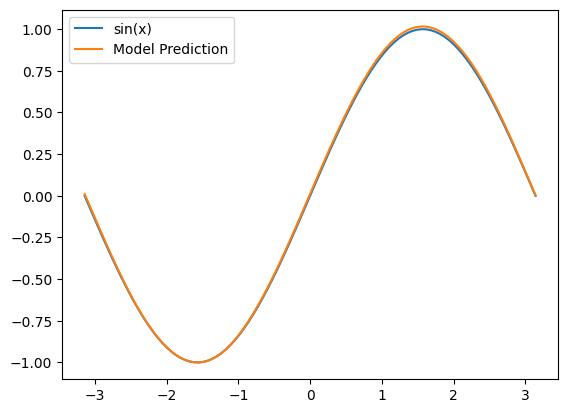

In [19]:

x = np.linspace(-math.pi, math.pi, 100)
plt.plot(x, np.sin(x), label='sin(x)')
pred = [model(torch.tensor([xi], dtype=torch.float32)).item() for xi in x]
plt.plot(x, pred, label='Model Prediction')
plt.legend()
plt.show()

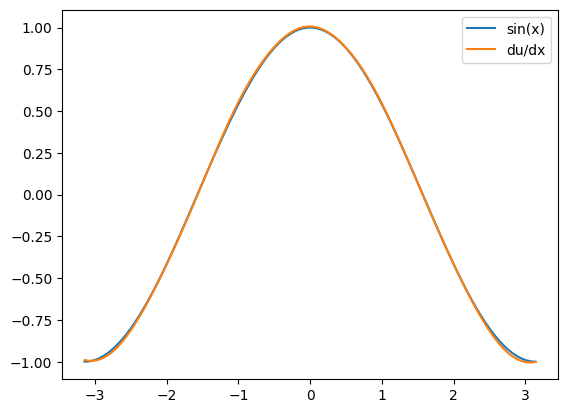

In [22]:
# recompute outputs and derivative over the grid, then plot
x_np = np.linspace(-math.pi, math.pi, 100)
x_t = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1).requires_grad_(True)  # shape (100,1)
u = model(x_t)  # shape (100,1)
du_dx = torch.autograd.grad(u, x_t, grad_outputs=torch.ones_like(u), create_graph=True)[0]  # shape (100,1)

pred = u.detach().numpy().squeeze()
du = du_dx.detach().numpy().squeeze()

plt.plot(x_np, np.cos(x_np), label='sin(x)')
plt.plot(x_np, du, label='du/dx')
plt.legend()
plt.show()

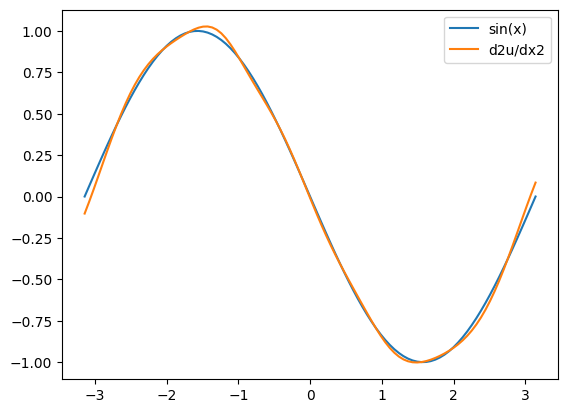

In [21]:
# recompute outputs and derivative over the grid, then plot
x_np = np.linspace(-math.pi, math.pi, 100)
x_t = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1).requires_grad_(True)  # shape (100,1)
u = model(x_t)  # shape (100,1)
du_dx = torch.autograd.grad(u, x_t, grad_outputs=torch.ones_like(u), create_graph=True)[0]  # shape (100,1)
d2u_dx2 = torch.autograd.grad(du_dx, x_t, grad_outputs=torch.ones_like(du_dx))[0]  # shape (100,1)
d2u_dx2 = d2u_dx2.detach().numpy().squeeze()
pred = u.detach().numpy().squeeze()
du = du_dx.detach().numpy().squeeze()

plt.plot(x_np, -np.sin(x_np), label='sin(x)')
plt.plot(x_np, d2u_dx2, label='d2u/dx2')
plt.legend()
plt.show()